# 5.1.1 Dimension-Factor Correlation Analysis (Strict Statistics)

This notebook performs a rigorous correlation analysis between VAE latent dimensions and clinical factors.
It implements strict filtering and statistical correction to identify robust signals.

## Methodology
1. **KL Filtering (Active Units)**: Only dimensions with Mean KL Divergence > Threshold (or High Variance) are analyzed.
2. **Strict Significance**: Bonferroni correction is applied to control the Family-Wise Error Rate (FWER).
   - $\alpha_{corrected} = 0.05 / N_{active}$
3. **Ranking & Separation**: The top dimension matches must pass the corrected significance threshold and are evaluated on separation quality (Gap %).

## Factors Analyzed
- **Age** (Continuous) -> Pearson Correlation
- **Sex** (Binary) -> Point-Biserial Correlation
- **SBR (PC1)** (Continuous) -> Pearson Correlation
- **Scanner** (Categorical) -> Eta-Squared (${\eta}^2$)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pointbiserialr, f_oneway
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4e' % x)

## 1. Parameterization & Data Loading

In [187]:
# --- PARAMETERS ---
TARGET_BETA = "3.00e-05"
KL_THRESHOLD = 0.05
ALPHA_LEVEL = 0.05

# Paths
LATENT_CSV = "output/final_train_combined_vae_data.csv"
# Optional: Path to a pre-computed KL divergence CSV. 
# If file not found, we use Latent Variance as a proxy for activity.
KL_CSV_PATH = f"output/Experiments/BetaScanVAE/beta_scan_results/beta_{TARGET_BETA}/kl_divergence.csv"

print(f"Target Beta Model: {TARGET_BETA}")
print(f"KL Threshold for Active Units: {KL_THRESHOLD}")
print(f"Initial Significance Level: {ALPHA_LEVEL}")

Target Beta Model: 3.00e-05
KL Threshold for Active Units: 0.05
Initial Significance Level: 0.05


In [188]:
# Load Main Data
if os.path.exists(LATENT_CSV):
    df_latent = pd.read_csv(LATENT_CSV)
    print(f"Loaded Latent Data: {df_latent.shape}")
else:
    raise FileNotFoundError(f"Latent data not found at {LATENT_CSV}. Please run 5.0_prepare_csv_data_vae.ipynb first.")

# Define Latent Columns (latent_0 ... latent_255)
DIM_COLS = [c for c in df_latent.columns if c.startswith('latent_')]
print(f"Total Latent Dimensions: {len(DIM_COLS)}")

Loaded Latent Data: (2373, 303)
Total Latent Dimensions: 256


In [189]:
SBR_COLS = [
    'DATSCAN_CAUDATE_R', 'DATSCAN_CAUDATE_L',
    'DATSCAN_PUTAMEN_R', 'DATSCAN_PUTAMEN_L',
    'DATSCAN_PUTAMEN_R_ANT', 'DATSCAN_PUTAMEN_L_ANT'
]

RANDOM_STATE = 42

# Filter to rows with complete SBR data
df_with_sbr = df_latent.dropna(subset=SBR_COLS).copy()
print(f"Rows with complete SBR data: {len(df_with_sbr)}")

# Standardize and apply PCA
scaler_sbr = StandardScaler()
sbr_scaled = scaler_sbr.fit_transform(df_with_sbr[SBR_COLS])
pca = PCA(n_components=3, random_state=RANDOM_STATE)
sbr_pcs = pca.fit_transform(sbr_scaled)

df_with_sbr['SBR_PC1'] = sbr_pcs[:, 0]
df_with_sbr['SBR_PC2'] = sbr_pcs[:, 1]
df_with_sbr['SBR_PC3'] = sbr_pcs[:, 2]

print(f"\nSBR PCA explained variance: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

# Use this as final dataset
df_final = df_with_sbr.reset_index(drop=True)
print(f"\nFinal dataset: {df_final.shape}")
print(f"Unique patients: {df_final['PATNO'].nunique()}")

Rows with complete SBR data: 2373

SBR PCA explained variance: [0.88338287 0.05277345 0.04814441]
Total variance explained: 98.43%

Final dataset: (2373, 306)
Unique patients: 1437


## 2. Active Unit Filtering (Request #1)
We filter out "collapsed" dimensions (posterior collapse). Valid dimensions must have significant information content.

In [190]:
active_features = []
kl_values = {}

# Check if specific KL file exists
if os.path.exists(KL_CSV_PATH):
    print(f"Loading KL Divergence from: {KL_CSV_PATH}")
    df_kl = pd.read_csv(KL_CSV_PATH)
    # Assuming format: dimension, mean_kl
    for _, row in df_kl.iterrows():
        if row['mean_kl'] > KL_THRESHOLD:
            active_features.append(row['dimension'])
            kl_values[row['dimension']] = row['mean_kl']
else:
    print("Warning: KL Divergence file not found. Using Latent Variance as proxy for activity.")
    print(f"(Threshold > {KL_THRESHOLD})")
    
    variances = df_latent[DIM_COLS].var()
    for dim, var in variances.items():
        # In VAEs, collapsed units often have variance close to 0 (or close to prior)
        # Here we assume active units have variance significantly > threshold
        if var > KL_THRESHOLD:
            active_features.append(dim)
            kl_values[dim] = var # Storing variance as proxy metric

ACTIVE_FEATURES = sorted(active_features, key=lambda x: int(x.split('_')[1]))
N_ACTIVE = len(ACTIVE_FEATURES)

print(f"\nActive Dimensions identified: {N_ACTIVE} / {len(DIM_COLS)}")
print(f"Collapsed Dimensions: {len(DIM_COLS) - N_ACTIVE}")

Loading KL Divergence from: output/Experiments/BetaScanVAE/beta_scan_results/beta_3.00e-05/kl_divergence.csv

Active Dimensions identified: 67 / 256
Collapsed Dimensions: 189


## 3. Statistical Correction (Request #2)
Calculating Bonferroni-corrected significance threshold.

In [191]:
if N_ACTIVE > 0:
    ALPHA_CORRECTED = ALPHA_LEVEL / N_ACTIVE
else:
    ALPHA_CORRECTED = ALPHA_LEVEL # Fallback to avoid division by zero if all collapsed
    
print(f"Bonferroni Corrected Alpha: {ALPHA_CORRECTED:.2e}")
print(f"(Base Alpha {ALPHA_LEVEL} / {N_ACTIVE} Tests)")

Bonferroni Corrected Alpha: 7.46e-04
(Base Alpha 0.05 / 67 Tests)


## 4. Correlation Analysis Modules (Request #4)
Functions to compute correlations and rank dimensions.

In [282]:
def analyze_factor(data, factor_col, factor_type, active_dims, alpha_threshold):
    results = []
    
    # Remove NaNs for this factor
    valid_data = data.dropna(subset=[factor_col])
    if len(valid_data) < 5:
        print(f"Not enough data for {factor_col}")
        return pd.DataFrame()
    
    y = valid_data[factor_col]
    
    for dim in active_dims:
        x = valid_data[dim]
        
        stat = 0
        p_val = 1.0
        effect_size = 0
        
        if factor_type == 'continuous':
            # Pearson Correlation - Effect size as r²
            r, p = stats.pearsonr(x, y)
            stat = r
            p_val = p
            effect_size = r**2  # Changed from abs(r) to r²
            
        elif factor_type == 'binary':
            # Point Biserial - Effect size as r²
            r, p = pointbiserialr(y, x)
            stat = r
            p_val = p
            effect_size = r**2  # Changed from abs(r) to r²
            
        elif factor_type == 'categorical':
            # Eta-Squared (from ANOVA) - already η²
            groups = [valid_data[valid_data[factor_col] == g][dim] for g in y.unique()]
            if len(groups) > 1:
                f_stat, p = f_oneway(*groups)
                # Calculate Eta-Squared: SS_between / SS_total
                k = len(groups)
                N = len(valid_data)
                eta2 = (f_stat * (k - 1)) / (f_stat * (k - 1) + (N - k))
                
                stat = f_stat
                p_val = p
                effect_size = eta2  # Already η²
            else:
                continue
                
        results.append({
            'Dimension': dim,
            'Statistic': stat,
            'Effect_Size': effect_size,
            'P_Value': p_val,
            'Survives_Correction': p_val < alpha_threshold
        })
        
    res_df = pd.DataFrame(results)
    if not res_df.empty:
        res_df = res_df.sort_values(by='Effect_Size', ascending=False).reset_index(drop=True)
        res_df['Rank'] = res_df.index + 1
        
    return res_df

def interpret_gap(gap_pct):
    if gap_pct >= 20: return "Excellent"
    if gap_pct >= 10: return "Good"
    if gap_pct >= 5:  return "Moderate"
    return "Weak"

## 5. Execution & Summary Generation

In [283]:
factors_config = [
    {'name': 'Age', 'col': 'AGE_AT_VISIT', 'type': 'continuous'},
    {'name': 'Sex', 'col': 'SEX', 'type': 'binary'},
    {'name': 'Scanner', 'col': 'Manufacturer', 'type': 'categorical'},
    {'name': 'Scanner Model', 'col': 'ManufacturerModelName', 'type': 'categorical'},
    {'name': 'Patient Hand', 'col': 'HANDED', 'type': 'categorical'},
    {'name': 'SBR_PC1', 'col': 'SBR_PC1', 'type': 'continuous'},
    {'name': 'SBR_PC2', 'col': 'SBR_PC2', 'type': 'continuous'},
    {'name': 'SBR_PC3', 'col': 'SBR_PC3', 'type': 'continuous'}
]

summary_rows = []

for factor in factors_config:
    print(f"\nAnalyzing Factor: {factor['name']}...")
    df_res = analyze_factor(df_final, factor['col'], factor['type'], ACTIVE_FEATURES, ALPHA_CORRECTED)
    
    if df_res.empty:
        print("No results.")
        continue
        
    # Get Top 2 for Gap Analysis
    top_1 = df_res.iloc[0]
    top_2 = df_res.iloc[1] if len(df_res) > 1 else None
    
    gap_abs = 0.0
    gap_pct = 0.0
    sep_quality = "N/A"
    
    if top_2 is not None:
        gap_abs = top_1['Effect_Size'] - top_2['Effect_Size']
        if top_1['Effect_Size'] > 0:
            gap_pct = (gap_abs / top_1['Effect_Size']) * 100
        sep_quality = interpret_gap(gap_pct)
        
    print(f"  Top Dimension: {top_1['Dimension']}")
    print(f"  Effect Size: {top_1['Effect_Size']:.4f}")
    print(f"  P-Value: {top_1['P_Value']:.4e} (Corrected Threshold: {ALPHA_CORRECTED:.2e})")
    print(f"  Survives Correction: {top_1['Survives_Correction']}")
    print(f"  Separation Gap: {gap_pct:.1f}% ({sep_quality})")
    
    # Add to summary if it survives correction
    if top_1['Survives_Correction']:
        summary_rows.append({
            'Factor': factor['name'],
            'Top_Dimension': top_1['Dimension'],
            'Effect_Size': top_1['Effect_Size'],
            'P_Value': top_1['P_Value'],
            'Survives_Bonferroni': True,
            'Separation_Gap_Pct': gap_pct,
            'Separation_Quality': sep_quality
        })
    else:
        # Optional: Add but mark as non-significant
        summary_rows.append({
            'Factor': factor['name'],
            'Top_Dimension': top_1['Dimension'],
            'Effect_Size': top_1['Effect_Size'],
            'P_Value': top_1['P_Value'],
            'Survives_Bonferroni': False,
            'Separation_Gap_Pct': gap_pct,
            'Separation_Quality': "Insignificant"
        })

df_summary = pd.DataFrame(summary_rows)

print("\n" + "="*60)
print(f"FINAL SUMMARY TABLE (Strict Statistics) ({TARGET_BETA})")
print("="*60)
if not df_summary.empty:
    print(df_summary[['Factor', 'Top_Dimension', 'Effect_Size', 'P_Value', 'Survives_Bonferroni', 'Separation_Quality']].to_string(index=False))
else:
    print("No factors produced significant dimensions passing strict statistical correction.")


Analyzing Factor: Age...
  Top Dimension: latent_72
  Effect Size: 0.0941
  P-Value: 7.7602e-53 (Corrected Threshold: 7.46e-04)
  Survives Correction: True
  Separation Gap: 7.3% (Moderate)

Analyzing Factor: Sex...
  Top Dimension: latent_133
  Effect Size: 0.0625
  P-Value: 4.2107e-35 (Corrected Threshold: 7.46e-04)
  Survives Correction: True
  Separation Gap: 26.0% (Excellent)

Analyzing Factor: Scanner...
  Top Dimension: latent_39
  Effect Size: 0.1784
  P-Value: 2.1929e-89 (Corrected Threshold: 7.46e-04)
  Survives Correction: True
  Separation Gap: 2.8% (Weak)

Analyzing Factor: Scanner Model...
  Top Dimension: latent_39
  Effect Size: 0.2066
  P-Value: 2.3439e-99 (Corrected Threshold: 7.46e-04)
  Survives Correction: True
  Separation Gap: 8.2% (Moderate)

Analyzing Factor: Patient Hand...
  Top Dimension: latent_142
  Effect Size: 0.0064
  P-Value: 5.0812e-04 (Corrected Threshold: 7.46e-04)
  Survives Correction: True
  Separation Gap: 9.2% (Moderate)

Analyzing Factor: SBR

In [323]:
# Store all factor results for heatmap generation
all_results = {}

for factor in factors_config:
    print(f"\nAnalyzing Factor: {factor['name']}...")
    df_res = analyze_factor(df_final, factor['col'], factor['type'], ACTIVE_FEATURES, ALPHA_CORRECTED)
    
    if df_res.empty:
        print("No results.")
        continue
    
    # Store results for heatmap
    all_results[factor['name']] = df_res
    
    # Get Top 2 for Gap Analysis
    top_1 = df_res.iloc[0]
    top_2 = df_res.iloc[1] if len(df_res) > 1 else None
    
    gap_abs = 0.0
    gap_pct = 0.0
    sep_quality = "N/A"
    
    if top_2 is not None:
        gap_abs = top_1['Effect_Size'] - top_2['Effect_Size']
        if top_1['Effect_Size'] > 0:
            gap_pct = (gap_abs / top_1['Effect_Size']) * 100
        sep_quality = interpret_gap(gap_pct)
        
    print(f"  Top Dimension: {top_1['Dimension']}")
    print(f"  Effect Size (r² or η²): {top_1['Effect_Size']:.4f}")
    print(f"  P-Value: {top_1['P_Value']:.4e} (Corrected Threshold: {ALPHA_CORRECTED:.2e})")
    print(f"  Survives Correction: {top_1['Survives_Correction']}")
    print(f"  Separation Gap: {gap_pct:.1f}% ({sep_quality})")
    
    # Add to summary if it survives correction
    if top_1['Survives_Correction']:
        summary_rows.append({
            'Factor': factor['name'],
            'Top_Dimension': top_1['Dimension'],
            'Effect_Size': top_1['Effect_Size'],
            'P_Value': top_1['P_Value'],
            'Survives_Bonferroni': True,
            'Separation_Gap_Pct': gap_pct,
            'Separation_Quality': sep_quality
        })
    else:
        summary_rows.append({
            'Factor': factor['name'],
            'Top_Dimension': top_1['Dimension'],
            'Effect_Size': top_1['Effect_Size'],
            'P_Value': top_1['P_Value'],
            'Survives_Bonferroni': False,
            'Separation_Gap_Pct': gap_pct,
            'Separation_Quality': "Insignificant"
        })

df_summary = pd.DataFrame(summary_rows)

print("\n" + "="*60)
print(f"FINAL SUMMARY TABLE (Strict Statistics) ({TARGET_BETA})")
print("="*60)
if not df_summary.empty:
    print(df_summary[['Factor', 'Top_Dimension', 'Effect_Size', 'P_Value', 'Survives_Bonferroni', 'Separation_Quality']].to_string(index=False))
else:
    print("No factors produced significant dimensions passing strict statistical correction.")


Analyzing Factor: Age...
  Top Dimension: latent_72
  Effect Size (r² or η²): 0.0941
  P-Value: 7.7602e-53 (Corrected Threshold: 7.46e-04)
  Survives Correction: True
  Separation Gap: 7.3% (Moderate)

Analyzing Factor: Sex...
  Top Dimension: latent_133
  Effect Size (r² or η²): 0.0625
  P-Value: 4.2107e-35 (Corrected Threshold: 7.46e-04)
  Survives Correction: True
  Separation Gap: 26.0% (Excellent)

Analyzing Factor: Scanner...
  Top Dimension: latent_39
  Effect Size (r² or η²): 0.1784
  P-Value: 2.1929e-89 (Corrected Threshold: 7.46e-04)
  Survives Correction: True
  Separation Gap: 2.8% (Weak)

Analyzing Factor: Scanner Model...
  Top Dimension: latent_39
  Effect Size (r² or η²): 0.2066
  P-Value: 2.3439e-99 (Corrected Threshold: 7.46e-04)
  Survives Correction: True
  Separation Gap: 8.2% (Moderate)

Analyzing Factor: Patient Hand...
  Top Dimension: latent_142
  Effect Size (r² or η²): 0.0064
  P-Value: 5.0812e-04 (Corrected Threshold: 7.46e-04)
  Survives Correction: True
 

In [324]:
# Create heatmap matrix: rows = latent dimensions, columns = factors
# Only include latents that have at least one significant correlation (after Bonferroni)

# Build the matrix
heatmap_data = []
latent_dims_in_heatmap = set()

# First pass: identify which latents are significant for at least one factor
for factor_name, df_res in all_results.items():
    significant_dims = df_res[df_res['Survives_Correction'] == True]['Dimension'].tolist()
    latent_dims_in_heatmap.update(significant_dims)

# Sort latent dimensions numerically
latent_dims_in_heatmap = sorted(latent_dims_in_heatmap, key=lambda x: int(x.split('_')[1]))

print(f"\nLatent dimensions with at least one significant correlation: {len(latent_dims_in_heatmap)}")

# Second pass: build the heatmap matrix
heatmap_matrix = pd.DataFrame(index=latent_dims_in_heatmap, columns=all_results.keys())

for factor_name, df_res in all_results.items():
    for dim in latent_dims_in_heatmap:
        # Find this dimension in the results
        dim_row = df_res[df_res['Dimension'] == dim]
        if not dim_row.empty:
            effect_size = dim_row.iloc[0]['Effect_Size']
            survives = dim_row.iloc[0]['Survives_Correction']
            # Only show effect size if it survives Bonferroni correction
            heatmap_matrix.loc[dim, factor_name] = effect_size if survives else 0.0
        else:
            heatmap_matrix.loc[dim, factor_name] = 0.0

# Convert to float
heatmap_matrix = heatmap_matrix.astype(float)

print(f"Heatmap matrix shape: {heatmap_matrix.shape}")
heatmap_matrix.head()


Latent dimensions with at least one significant correlation: 67
Heatmap matrix shape: (67, 8)


,Age,Sex,Scanner,Scanner Model,Patient Hand,SBR_PC1,SBR_PC2,SBR_PC3
latent_6,0.0000e+00,0.0000e+00,2.4093e-02,3.1762e-02,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00
latent_8,3.1164e-02,0.0000e+00,9.3777e-02,1.1272e-01,0.0000e+00,7.8946e-03,0.0000e+00,1.9953e-02
latent_10,2.2956e-02,4.6227e-02,5.0869e-02,5.8474e-02,0.0000e+00,2.4443e-02,0.0000e+00,4.8326e-02
latent_17,0.0000e+00,0.0000e+00,2.7473e-02,8.7478e-02,0.0000e+00,8.1091e-03,7.4496e-03,0.0000e+00
latent_18,0.0000e+00,0.0000e+00,6.9577e-02,7.5467e-02,0.0000e+00,3.0678e-02,0.0000e+00,5.7565e-02


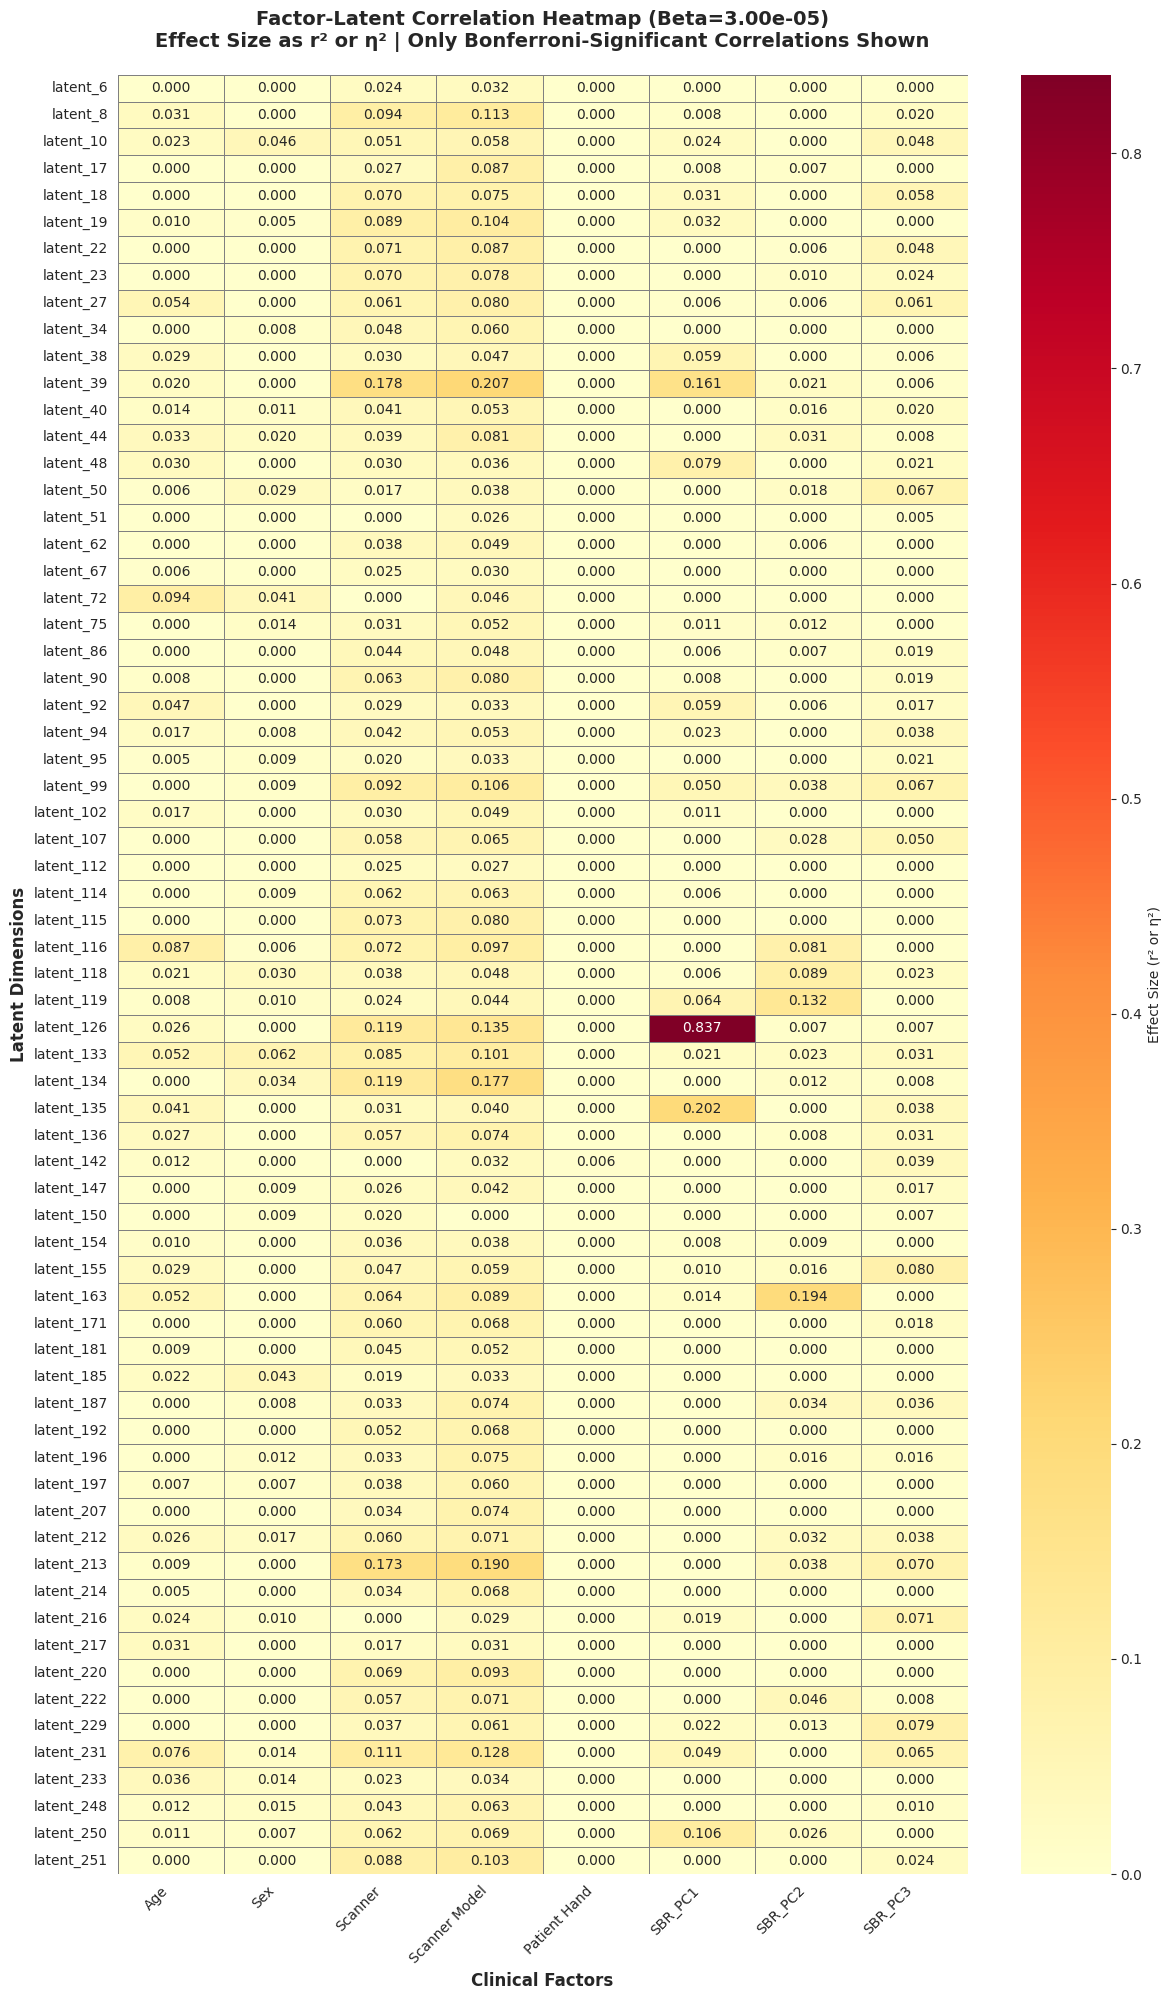


HEATMAP SUMMARY STATISTICS
Total latent dimensions shown: 67
Total factors analyzed: 8

Latents correlating with multiple factors:
  latent_133: 7 factors (Age, Sex, Scanner, Scanner Model, SBR_PC1, SBR_PC2, SBR_PC3)
  latent_118: 7 factors (Age, Sex, Scanner, Scanner Model, SBR_PC1, SBR_PC2, SBR_PC3)
  latent_39: 6 factors (Age, Scanner, Scanner Model, SBR_PC1, SBR_PC2, SBR_PC3)
  latent_212: 6 factors (Age, Sex, Scanner, Scanner Model, SBR_PC2, SBR_PC3)
  latent_250: 6 factors (Age, Sex, Scanner, Scanner Model, SBR_PC1, SBR_PC2)
  latent_119: 6 factors (Age, Sex, Scanner, Scanner Model, SBR_PC1, SBR_PC2)
  latent_231: 6 factors (Age, Sex, Scanner, Scanner Model, SBR_PC1, SBR_PC3)
  latent_27: 6 factors (Age, Scanner, Scanner Model, SBR_PC1, SBR_PC2, SBR_PC3)
  latent_40: 6 factors (Age, Sex, Scanner, Scanner Model, SBR_PC2, SBR_PC3)
  latent_155: 6 factors (Age, Scanner, Scanner Model, SBR_PC1, SBR_PC2, SBR_PC3)
  latent_99: 6 factors (Sex, Scanner, Scanner Model, SBR_PC1, SBR_PC2, 

In [286]:
# Create the heatmap visualization
fig, ax = plt.subplots(figsize=(12, max(8, len(latent_dims_in_heatmap) * 0.3)))

# Create heatmap
sns.heatmap(
    heatmap_matrix,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    cbar_kws={'label': 'Effect Size (r² or η²)'},
    linewidths=0.5,
    linecolor='gray',
    vmin=0,
    vmax=heatmap_matrix.max().max(),
    ax=ax
)

ax.set_title(f'Factor-Latent Correlation Heatmap (Beta={TARGET_BETA})\nEffect Size as r² or η² | Only Bonferroni-Significant Correlations Shown', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Clinical Factors', fontsize=12, fontweight='bold')
ax.set_ylabel('Latent Dimensions', fontsize=12, fontweight='bold')

# Rotate labels for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("HEATMAP SUMMARY STATISTICS")
print("="*60)
print(f"Total latent dimensions shown: {len(latent_dims_in_heatmap)}")
print(f"Total factors analyzed: {len(all_results)}")
print(f"\nLatents correlating with multiple factors:")

# Count how many factors each latent correlates with
latent_factor_counts = (heatmap_matrix > 0).sum(axis=1)
multi_factor_latents = latent_factor_counts[latent_factor_counts > 1].sort_values(ascending=False)

if len(multi_factor_latents) > 0:
    for dim, count in multi_factor_latents.items():
        factors_list = heatmap_matrix.loc[dim][heatmap_matrix.loc[dim] > 0].index.tolist()
        print(f"  {dim}: {int(count)} factors ({', '.join(factors_list)})")
else:
    print("  None - all latents are specific to single factors (good disentanglement!)")

print(f"\nMean effect size across all significant correlations: {heatmap_matrix[heatmap_matrix > 0].mean().mean():.4f}")

In [196]:
heatmap_matrix

,Age,Sex,Scanner,Scanner Model,Patient Hand,SBR_PC1,SBR_PC2,SBR_PC3
latent_6,0.0000e+00,0.0000e+00,2.4093e-02,3.1762e-02,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00
latent_8,3.1164e-02,0.0000e+00,9.3777e-02,1.1272e-01,0.0000e+00,7.8946e-03,0.0000e+00,1.9953e-02
latent_10,2.2956e-02,4.6227e-02,5.0869e-02,5.8474e-02,0.0000e+00,2.4443e-02,0.0000e+00,4.8326e-02
latent_17,0.0000e+00,0.0000e+00,2.7473e-02,8.7478e-02,0.0000e+00,8.1091e-03,7.4496e-03,0.0000e+00
latent_18,0.0000e+00,0.0000e+00,6.9577e-02,7.5467e-02,0.0000e+00,3.0678e-02,0.0000e+00,5.7565e-02
...,...,...,...,...,...,...,...,...
latent_231,7.6108e-02,1.4337e-02,1.1060e-01,1.2805e-01,0.0000e+00,4.9269e-02,0.0000e+00,6.4665e-02
latent_233,3.6257e-02,1.3643e-02,2.3209e-02,3.3994e-02,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00
latent_248,1.2380e-02,1.5001e-02,4.3489e-02,6.3147e-02,0.0000e+00,0.0000e+00,0.0000e+00,1.0010e-02
latent_250,1.0857e-02,6.8350e-03,6.1875e-02,6.8740e-02,0.0000e+00,1.0604e-01,2.5524e-02,0.0000e+00


In [197]:
# Save the heatmap matrix for future reference
heatmap_output_path = f"output/correlation_heatmap_matrix_{TARGET_BETA}.csv"
heatmap_matrix.to_csv(heatmap_output_path)
print(f"Heatmap matrix saved to: {heatmap_output_path}")

# Also save a version with dimension indices for easier analysis
heatmap_with_idx = heatmap_matrix.copy()
heatmap_with_idx.index = [int(dim.split('_')[1]) for dim in heatmap_with_idx.index]
heatmap_with_idx.index.name = 'Latent_Dimension_Index'

heatmap_idx_path = f"output/correlation_heatmap_indexed_{TARGET_BETA}.csv"
heatmap_with_idx.to_csv(heatmap_idx_path)
print(f"Indexed heatmap matrix saved to: {heatmap_idx_path}")

Heatmap matrix saved to: output/correlation_heatmap_matrix_3.00e-05.csv
Indexed heatmap matrix saved to: output/correlation_heatmap_indexed_3.00e-05.csv


In [198]:
# Optional: Save Results
if not df_summary.empty:
    output_path = f"output/strict_correlation_analysis_summary_{TARGET_BETA}.csv"
    df_summary.to_csv(output_path, index=False)
    print(f"\nSummary saved to: {output_path}")


Summary saved to: output/strict_correlation_analysis_summary_3.00e-05.csv


# Validation dataset

In [201]:
# Filter to rows with complete SBR data
# Apply scaling and PCA transform estimated on training dataset
df_val_sbr = df_val.dropna(subset=SBR_COLS).copy()

sbr_scaled = scaler_sbr.transform(df_val_sbr[SBR_COLS])
sbr_pcs = pca.transform(sbr_scaled)

df_val_sbr['SBR_PC1'] = sbr_pcs[:, 0]
df_val_sbr['SBR_PC2'] = sbr_pcs[:, 1]
df_val_sbr['SBR_PC3'] = sbr_pcs[:, 2]

val_final = df_val_sbr.reset_index(drop=True)


SBR PCA explained variance: [0.88338287 0.05277345 0.04814441]
Total variance explained: 98.43%


## Loading and preprocessing

In [199]:
#load validation dataset
VAL_CSV = "output/final_validation_combined_vae_data.csv"
df_val = pd.read_csv(VAL_CSV)

In [325]:
# Re-do the same analysis on the validation dataset
# As we're validating the previous results, consider a result validated if it was significant in the training dataset _AND_ it survives p<0.1  on the validation one

for factor in factors_config[:]:
    print(f"\nAnalyzing Factor: {factor['name']}...")
    df_res_val = analyze_factor(val_final, factor['col'], factor['type'], ACTIVE_FEATURES, 0.1)
    df_or = all_results[factor['name']]
    df_m = df_or.merge(df_res_val[['Dimension','Effect_Size','Statistic']],on='Dimension', suffixes=('', '_val'))
    df_m['Validated'] = (df_m['Survives_Correction']) & (df_m['Effect_Size_val']>0.007) & ((df_m['Statistic']*df_m['Statistic_val'])>0)
    all_results[factor['name']] = df_m


Analyzing Factor: Age...

Analyzing Factor: Sex...

Analyzing Factor: Scanner...

Analyzing Factor: Scanner Model...

Analyzing Factor: Patient Hand...

Analyzing Factor: SBR_PC1...

Analyzing Factor: SBR_PC2...

Analyzing Factor: SBR_PC3...


## Heatmap

In [326]:
# Create the validation heatmap
heatmap_matrix_val = pd.DataFrame(index=latent_dims_in_heatmap, columns=all_results.keys())

for factor_name, df_res in all_results.items():
    for dim in latent_dims_in_heatmap:
        # Find this dimension in the results
        dim_row = df_res[df_res['Dimension'] == dim]
        if not dim_row.empty:
            effect_size = dim_row.iloc[0]['Effect_Size_val']
            survives = dim_row.iloc[0]['Validated']
            # Only show effect size if it survives Bonferroni correction
            heatmap_matrix_val.loc[dim, factor_name] = effect_size if survives else 0.0
        else:
            heatmap_matrix_val.loc[dim, factor_name] = 0.0

# Convert to float
heatmap_matrix_val = heatmap_matrix.astype(float)


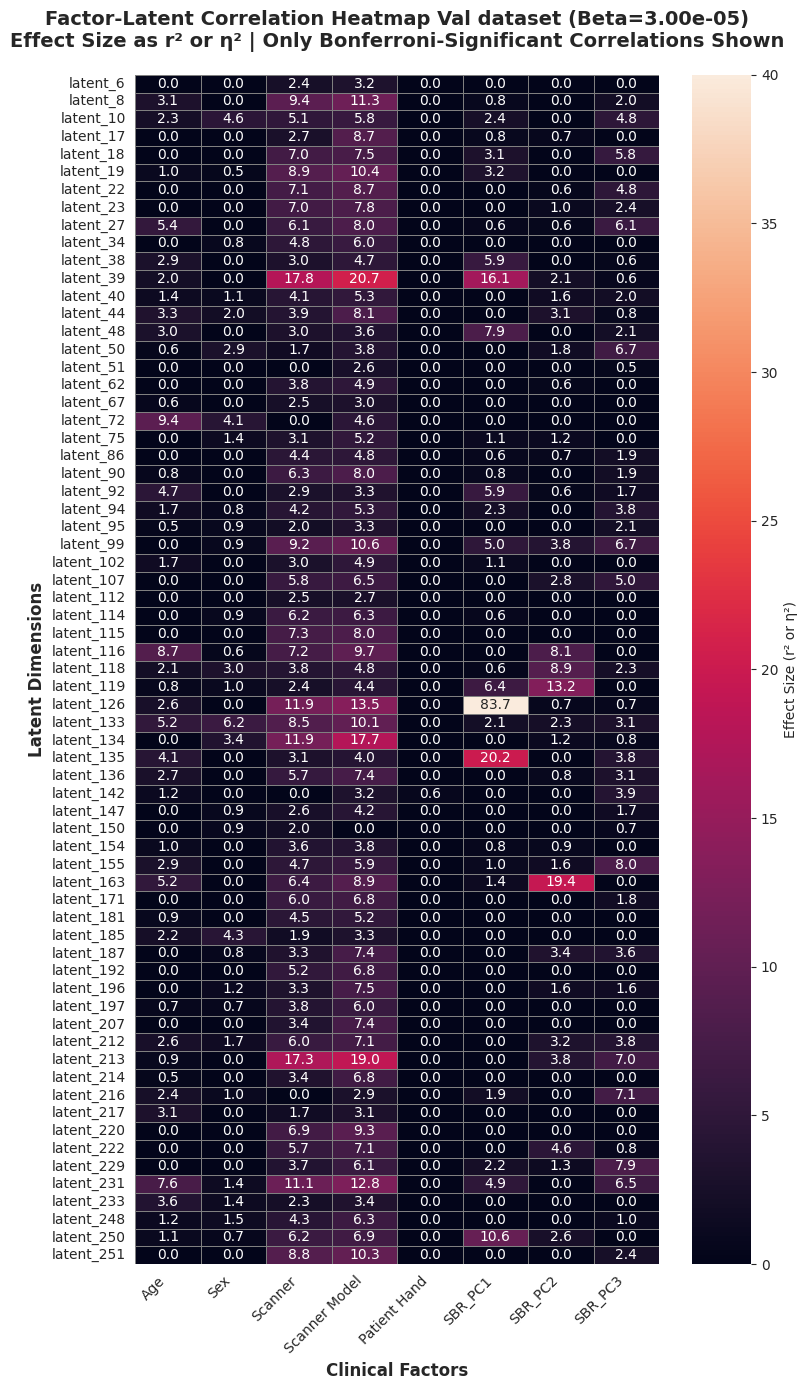

In [333]:
# Display the heatmap using % for better readability
fig, ax = plt.subplots(figsize=(8,14)) # max(8, len(latent_dims_in_heatmap) * 0.3)))

# Create heatmap
sns.heatmap(
    heatmap_matrix_val*100,
    annot=True,
    fmt='.1f',
    cmap='rocket',
    cbar_kws={'label': 'Effect Size (r² or η²)'},
    linewidths=0.5,
    linecolor='gray',
    vmin=0,
    vmax=40,# heatmap_matrix.max().max(),
    ax=ax
)

ax.set_title(f'Factor-Latent Correlation Heatmap Val dataset (Beta={TARGET_BETA})\nEffect Size as r² or η² | Only Bonferroni-Significant Correlations Shown', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Clinical Factors', fontsize=12, fontweight='bold')
ax.set_ylabel('Latent Dimensions', fontsize=12, fontweight='bold')

# Rotate labels for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## PD vs HC classification

Try classifying PD vs HC on latent dimensions (all or selected) using a simple SVM. Keep in mind they're very unbalanced in the dataset

In [454]:
from sklearn import svm
from sklearn.metrics import classification_report
clf = svm.SVC(kernel='linear',class_weight='balanced') 

### Selected dimensions

Train set
              precision    recall  f1-score   support

     Control       0.51      0.96      0.67       233
          PD       1.00      0.90      0.94      2030

    accuracy                           0.90      2263
   macro avg       0.76      0.93      0.81      2263
weighted avg       0.95      0.90      0.91      2263

Test set
              precision    recall  f1-score   support

     Control       0.49      0.93      0.64        56
          PD       0.99      0.89      0.94       508

    accuracy                           0.90       564
   macro avg       0.74      0.91      0.79       564
weighted avg       0.94      0.90      0.91       564



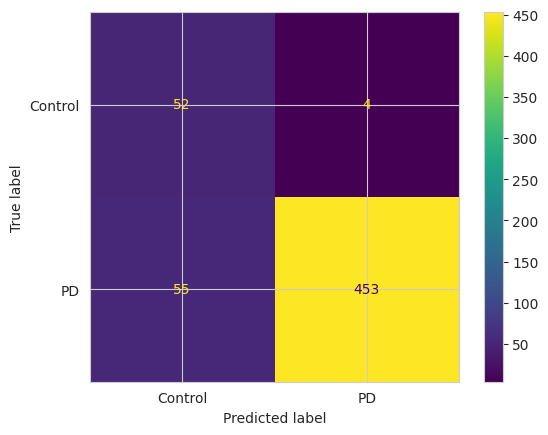

In [455]:
clf.fit(df_latent[df_latent['label']!='SWEDD'][['latent_126','latent_135','latent_163','latent_50']],df_latent[df_latent['label']!='SWEDD']['label'])
#clf.score(df_latent[df_latent['label']!='SWEDD'][['latent_126','latent_135','latent_163','latent_50']],df_latent[df_latent['label']!='SWEDD']['label'])
#clf.score(val_final[val_final['label']!='SWEDD'][['latent_126','latent_135','latent_163','latent_50']],val_final[val_final['label']!='SWEDD']['label'])
print(80*'=')
print('Train set')
print(80*'=')
print(classification_report(df_latent[df_latent['label']!='SWEDD']['label'],clf.predict(df_latent[df_latent['label']!='SWEDD'][['latent_126','latent_135','latent_163','latent_50']])))
print(80*'=')
print('Test set')
print(80*'=')
print(classification_report(val_final[val_final['label']!='SWEDD']['label'],clf.predict(val_final[val_final['label']!='SWEDD'][['latent_126','latent_135','latent_163','latent_50']])))
ConfusionMatrixDisplay.from_estimator(clf,val_final[val_final['label']!='SWEDD'][['latent_126','latent_135','latent_163','latent_50']],val_final[val_final['label']!='SWEDD']['label'])

### All dimensions

Train set
              precision    recall  f1-score   support

     Control       0.72      1.00      0.84       233
          PD       1.00      0.96      0.98      2030

    accuracy                           0.96      2263
   macro avg       0.86      0.98      0.91      2263
weighted avg       0.97      0.96      0.96      2263

Test set
              precision    recall  f1-score   support

     Control       0.72      0.96      0.82        56
          PD       1.00      0.96      0.98       508

    accuracy                           0.96       564
   macro avg       0.86      0.96      0.90       564
weighted avg       0.97      0.96      0.96       564



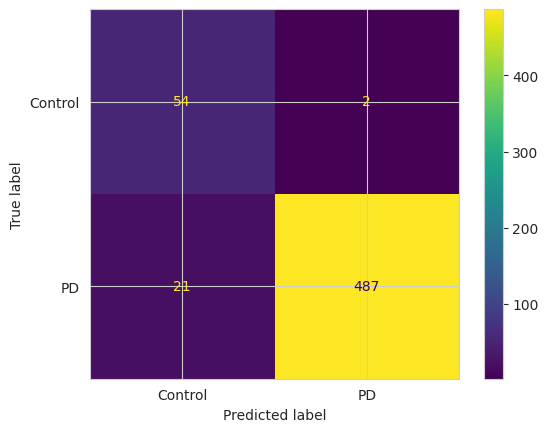

In [456]:
clf.fit(df_latent[df_latent['label']!='SWEDD'][ACTIVE_FEATURES],df_latent[df_latent['label']!='SWEDD']['label'])
print(80*'=')
print('Train set')
print(80*'=')
print(classification_report(df_latent[df_latent['label']!='SWEDD']['label'],clf.predict(df_latent[df_latent['label']!='SWEDD'][ACTIVE_FEATURES])))
print(80*'=')
print('Test set')
print(80*'=')
print(classification_report(val_final[val_final['label']!='SWEDD']['label'],clf.predict(val_final[val_final['label']!='SWEDD'][ACTIVE_FEATURES])))
ConfusionMatrixDisplay.from_estimator(clf,val_final[val_final['label']!='SWEDD'][ACTIVE_FEATURES],val_final[val_final['label']!='SWEDD']['label'])

## Test SBR vs scanner


In [570]:
# Rename identical scanners

lookup = {
    "ENCORE2": "Encore2",
    "3000XP": "P3000XP",
}
df_final["scanner"] = df_final["ManufacturerModelName"].map(lookup).fillna(
    df_final["ManufacturerModelName"]
)
val_final["scanner"] = val_final["ManufacturerModelName"].map(lookup).fillna(
    val_final["ManufacturerModelName"]
)

In [481]:
# Removes labels which are not scanners, run analysis only on scanners that have enough subjects
invalid_labels = {"HERMES Workstation","PMOD"}
counts = df_final['scanner'].value_counts()
too_small = set(counts[counts < 10].index)
excluded = invalid_labels | too_small
df_clean = df_final[~df_final['scanner'].isin(excluded)]
df_clean['scanner'].value_counts()

scanner
Encore2                     960
P3000XP                     285
IP2                         214
INFINIA                     191
BrightView                  185
MILLENNIUM MG               120
Tandem_Optima_640            51
Tandem_Discovery_630         46
VARICAM                      33
2000XP                       32
Forte                        25
IRIX                         22
Tandem_Discovery_670_Pro     21
MILLENNIUM MPS               14
Tandem_830                   13
Tandem_Discovery_670         12
Name: count, dtype: int64

In [548]:
val_clean = val_final[~val_final['scanner'].isin(excluded)]
val_clean['scanner'].value_counts()

scanner
Encore2                     255
P3000XP                      66
IP2                          53
BrightView                   47
INFINIA                      36
MILLENNIUM MG                31
Tandem_Optima_640            14
Tandem_Discovery_630         14
2000XP                       10
Forte                         9
VARICAM                       8
IRIX                          6
Tandem_830                    5
Tandem_Discovery_670_Pro      2
MILLENNIUM MPS                2
Tandem_Discovery_670          2
Name: count, dtype: int64

In [520]:
y = df_clean['scanner']
etaL = []
for dim in ACTIVE_FEATURES:
    groups = [df_clean[df_clean['scanner'] == g][dim] for g in y.unique()]
    f_stat, p = f_oneway(*groups)
    # Calculate Eta-Squared: SS_between / SS_total
    k = len(groups)
    N = len(df_clean)
    eta2 = (f_stat * (k - 1)) / (f_stat * (k - 1) + (N - k))
    
    stat = f_stat
    p_val = p
    effect_size = eta2  # Already η²
    etaL.append(eta2)

In [527]:
etaDF = pd.DataFrame(list(zip(etaL,ACTIVE_FEATURES)),columns=('eta','dim'))

In [533]:
etaDF.sort_values('eta',ascending=False)[:10]

,eta,dim
11,2.2345e-01,latent_39
55,1.9127e-01,latent_213
37,1.5688e-01,latent_134
35,1.1805e-01,latent_126
62,1.0500e-01,latent_231
26,1.0484e-01,latent_99
66,1.0383e-01,latent_251
1,1.0042e-01,latent_8
59,9.2708e-02,latent_220
5,9.0634e-02,latent_19


In [550]:
groupsMult = [df_clean[df_clean['scanner'] == g][['latent_39','latent_134','latent_213','latent_126','latent_231','latent_99','latent_251','latent_8']] for g in y.unique()]
valMult = [val_clean[val_clean['scanner'] == g][['latent_39','latent_134','latent_213','latent_126','latent_231','latent_99','latent_251','latent_8']] for g in y.unique()]

In [551]:
xc = np.zeros((16,8))
xcv = xc.copy()
for idx in range(16):
    xc[idx,:] = groupsMult[idx].mean()
    xcv[idx,:] = valMult[idx].mean()

In [552]:
distM = np.zeros((16,16))
distVal = np.zeros((16,16))
for idx in range(16):
    for idx2 in range(16):
        distM[idx,idx2]= np.sqrt(np.sum(xc[idx,:]-xc[idx2,:])**2)
        distVal[idx,idx2] = np.sqrt(np.sum(xcv[idx,:]-xcv[idx2,:])**2)

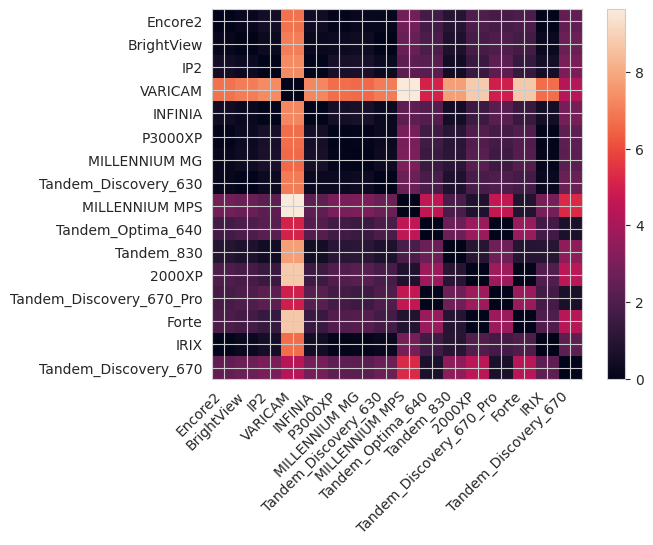

In [553]:
labV = y.unique()
plt.imshow(distM)
plt.colorbar()
plt.xticks(ticks=np.arange(16), 
           labels=labV) 
_=plt.yticks(ticks=np.arange(16), 
           labels=labV)
_=plt.xticks(rotation=45, ha='right')

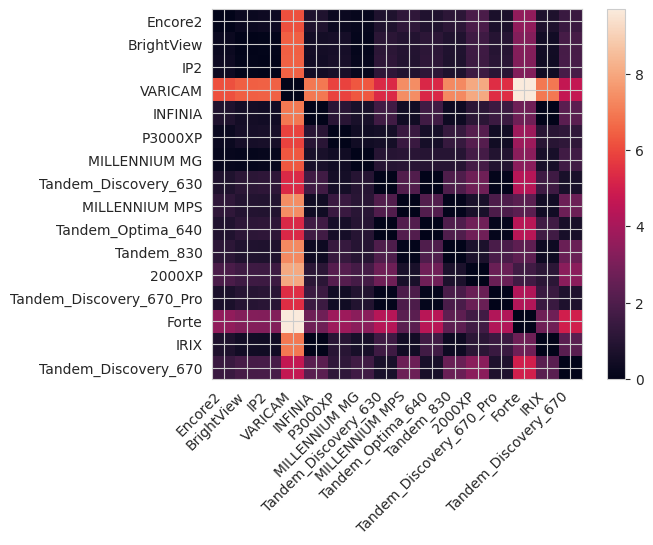

In [554]:
labV = y.unique()
plt.imshow(distVal)
plt.colorbar()
plt.xticks(ticks=np.arange(16), 
           labels=labV) 
_=plt.yticks(ticks=np.arange(16), 
           labels=labV)
_=plt.xticks(rotation=45, ha='right')

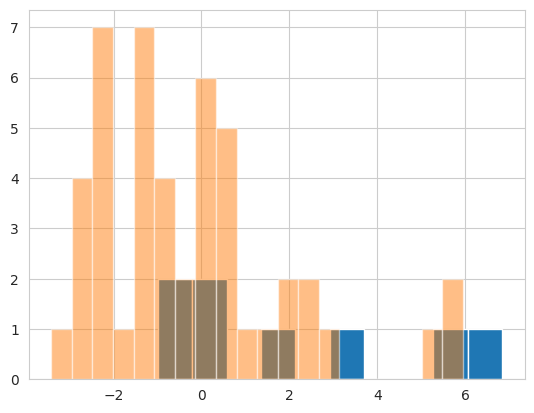

In [598]:
_=plt.hist(val_clean[val_clean['scanner']=='VARICAM']['SBR_PC1'])
_=plt.hist(val_clean[val_clean['scanner']=='BrightView']['SBR_PC1'],20,alpha=.5)

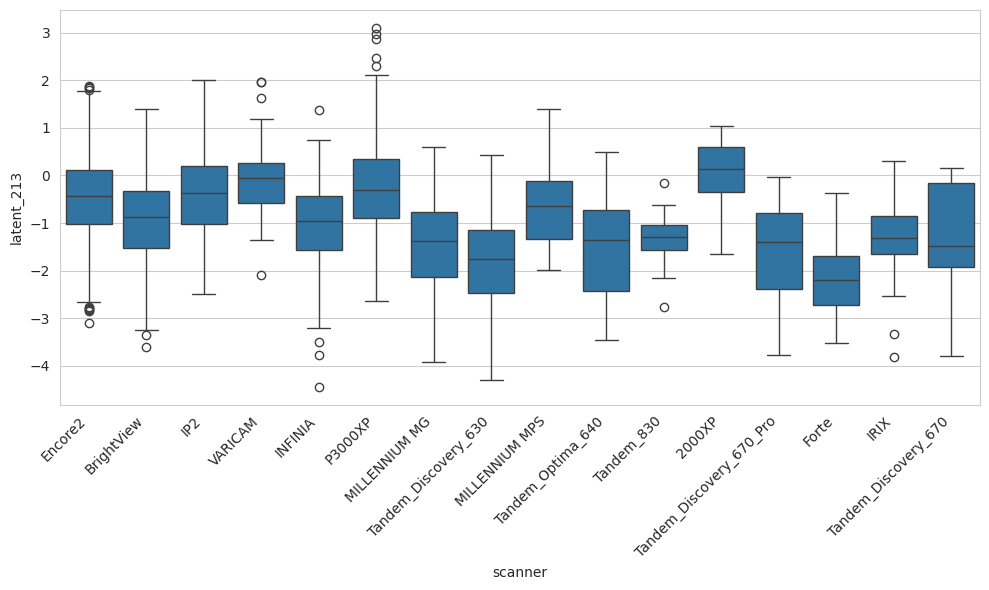

In [600]:

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_clean,
    x="scanner",
    y="latent_213",   # your dependent variable
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Predict Sex

In [560]:
from sklearn.ensemble import RandomForestClassifier
df_f_clean = df_final.dropna(subset='SEX')
# Suppose df is your DataFrame
predictors = ['latent_133','latent_10','latent_185','latent_72','latent_134']   # your 5 predictor columns
target = 'SEX'                     # your target column

X = df_f_clean[predictors]
y = df_f_clean[target]

model = RandomForestClassifier(min_samples_leaf=20)
model.fit(X, y)

#print(model.predict(X))


RandomForestClassifier(min_samples_leaf=20)

In [561]:
vf_clean = val_final.dropna(subset='SEX')
Xv = vf_clean[predictors]
yv = vf_clean[target]
model.score(X,y),model.score(Xv,yv)

(0.7612821594264023, 0.6835871404399323)

In [562]:
Xv.shape

(591, 5)

In [563]:
from sklearn.metrics import ConfusionMatrixDisplay

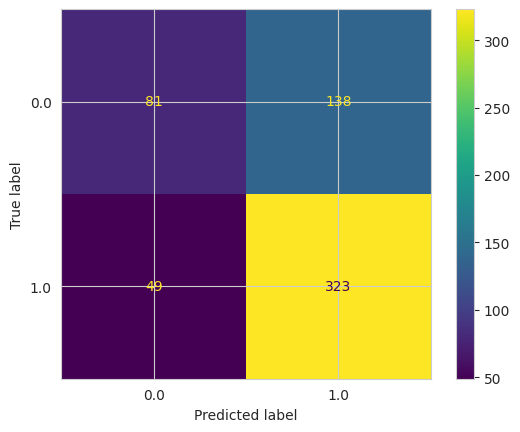

In [564]:
ConfusionMatrixDisplay.from_estimator(model,Xv,yv)

In [565]:
from sklearn.ensemble import RandomForestRegressor
df_f_clean = df_final.dropna(subset='AGE_AT_VISIT')
# Suppose df is your DataFrame
predictors = ['latent_72','latent_116','latent_231','latent_27','latent_133']   # your 5 predictor columns
target = 'AGE_AT_VISIT'                     # your target column

X = df_f_clean[predictors]
y = df_f_clean[target]

model = RandomForestRegressor(min_samples_leaf=10)
model.fit(X, y)

RandomForestRegressor(min_samples_leaf=10)

In [601]:
#abshelp (model.score)
Xv = vf_clean[predictors]
yv = vf_clean[target]
model.score(X,y),model.score(Xv,yv)

(0.5515143964452447, 0.3219381692481349)

### ANCOVA Analysis

In [605]:
# Additional imports for ANCOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set style for visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [606]:
def ancova_scanner_effect(data, latent_dim, scanner_col='Manufacturer', covariate_col='SBR_PC1'):
    """
    Perform ANCOVA to test scanner effect on latent dimension while controlling for SBR.
    
    Model: latent_dim ~ scanner + SBR_covariate
    
    Returns dict with statistics for the scanner effect after controlling for SBR.
    """
    # Prepare the data
    analysis_df = data[[latent_dim, scanner_col, covariate_col]].dropna().copy()
    
    # Build the ANCOVA model formula
    formula = f"{latent_dim} ~ C({scanner_col}) + {covariate_col}"
    
    # Fit the OLS model
    model = ols(formula, data=analysis_df).fit()
    
    # Get the ANOVA table (Type II SS)
    anova_table = sm.stats.anova_lm(model, typ=2)
    
    # Extract scanner effect statistics
    scanner_key = f'C({scanner_col})'
    scanner_ss = anova_table.loc[scanner_key, 'sum_sq']
    scanner_f = anova_table.loc[scanner_key, 'F']
    scanner_p = anova_table.loc[scanner_key, 'PR(>F)']
    
    # Extract covariate statistics
    cov_ss = anova_table.loc[covariate_col, 'sum_sq']
    cov_f = anova_table.loc[covariate_col, 'F']
    cov_p = anova_table.loc[covariate_col, 'PR(>F)']
    
    # Residual SS
    residual_ss = anova_table.loc['Residual', 'sum_sq']
    
    # Calculate partial eta-squared
    scanner_partial_eta_sq = scanner_ss / (scanner_ss + residual_ss)
    cov_partial_eta_sq = cov_ss / (cov_ss + residual_ss)
    
    return {
        'Dimension': latent_dim,
        'Covariate': covariate_col,
        'Scanner_F': scanner_f,
        'Scanner_p': scanner_p,
        'Scanner_Partial_Eta_Sq': scanner_partial_eta_sq,
        'Covariate_F': cov_f,
        'Covariate_p': cov_p,
        'Covariate_Partial_Eta_Sq': cov_partial_eta_sq,
        'Model_R_squared': model.rsquared,
        'Model_Adj_R_squared': model.rsquared_adj,
        'N_observations': len(analysis_df),
        'anova_table': anova_table,
        'model': model
    }

In [607]:
# Run ANCOVA for each active dimension with SBR_PC1 as covariate
print("=" * 70)
print("ANCOVA Analysis: Scanner Effect Controlling for SBR_PC1")
print("=" * 70)

ancova_results = []
scanner_col = 'Manufacturer'  # Or use 'ManufacturerModelName' for more granular
covariate_col = 'SBR_PC1'

for dim in ACTIVE_FEATURES:
    try:
        result = ancova_scanner_effect(
            df_final, 
            latent_dim=dim, 
            scanner_col=scanner_col,
            covariate_col=covariate_col
        )
        # Store result without the model object for DataFrame
        result_for_df = {k: v for k, v in result.items() if k not in ['anova_table', 'model']}
        ancova_results.append(result_for_df)
    except Exception as e:
        print(f"Error processing {dim}: {e}")

# Convert to DataFrame
df_ancova = pd.DataFrame(ancova_results)

# Apply Bonferroni correction
df_ancova['Scanner_Survives_Bonferroni'] = df_ancova['Scanner_p'] < ALPHA_CORRECTED
df_ancova['Cov_Survives_Bonferroni'] = df_ancova['Covariate_p'] < ALPHA_CORRECTED

# Sort by scanner partial eta-squared
df_ancova = df_ancova.sort_values('Scanner_Partial_Eta_Sq', ascending=False).reset_index(drop=True)

print(f"\nActive dimensions analyzed: {len(df_ancova)}")
print(f"Bonferroni-corrected alpha: {ALPHA_CORRECTED:.2e}")
print(f"\nDimensions with significant Scanner effect (after controlling for {covariate_col}):")
print(f"  {df_ancova['Scanner_Survives_Bonferroni'].sum()} / {len(df_ancova)}")

ANCOVA Analysis: Scanner Effect Controlling for SBR_PC1

Active dimensions analyzed: 67
Bonferroni-corrected alpha: 7.46e-04

Dimensions with significant Scanner effect (after controlling for SBR_PC1):
  64 / 67


In [608]:
# Display top results
print("\n" + "=" * 80)
print("TOP 20 Latent Dimensions by Scanner Effect (Partial η²) - Controlling for SBR_PC1")
print("=" * 80)

display_cols = ['Dimension', 'Scanner_F', 'Scanner_p', 'Scanner_Partial_Eta_Sq', 
                'Scanner_Survives_Bonferroni', 'Covariate_Partial_Eta_Sq', 'Model_R_squared']

print(df_ancova[display_cols].head(20).to_string(index=False))

# Also show summary statistics
print("\n" + "-" * 80)
print("Summary Statistics:")
print(f"  Mean Scanner Partial η²: {df_ancova['Scanner_Partial_Eta_Sq'].mean():.4f}")
print(f"  Max Scanner Partial η²: {df_ancova['Scanner_Partial_Eta_Sq'].max():.4f}")
print(f"  Mean Covariate Partial η²: {df_ancova['Covariate_Partial_Eta_Sq'].mean():.4f}")
print(f"  Mean Model R²: {df_ancova['Model_R_squared'].mean():.4f}")


TOP 20 Latent Dimensions by Scanner Effect (Partial η²) - Controlling for SBR_PC1
 Dimension  Scanner_F   Scanner_p  Scanner_Partial_Eta_Sq  Scanner_Survives_Bonferroni  Covariate_Partial_Eta_Sq  Model_R_squared
 latent_39 4.9782e+01 6.9221e-129              2.4075e-01                         True                2.2490e-01       3.6314e-01
latent_213 3.2078e+01  4.2682e-84              1.6965e-01                         True                3.2814e-07       1.7343e-01
latent_231 2.2742e+01  5.0334e-59              1.2652e-01                         True                6.6300e-02       1.6957e-01
latent_134 2.0980e+01  3.4646e-54              1.1788e-01                         True                2.1494e-05       1.1890e-01
 latent_99 2.0167e+01  6.0800e-52              1.1383e-01                         True                7.2449e-02       1.5811e-01
latent_250 1.7947e+01  8.7433e-46              1.0258e-01                         True                1.4484e-01       1.9775e-01
 latent

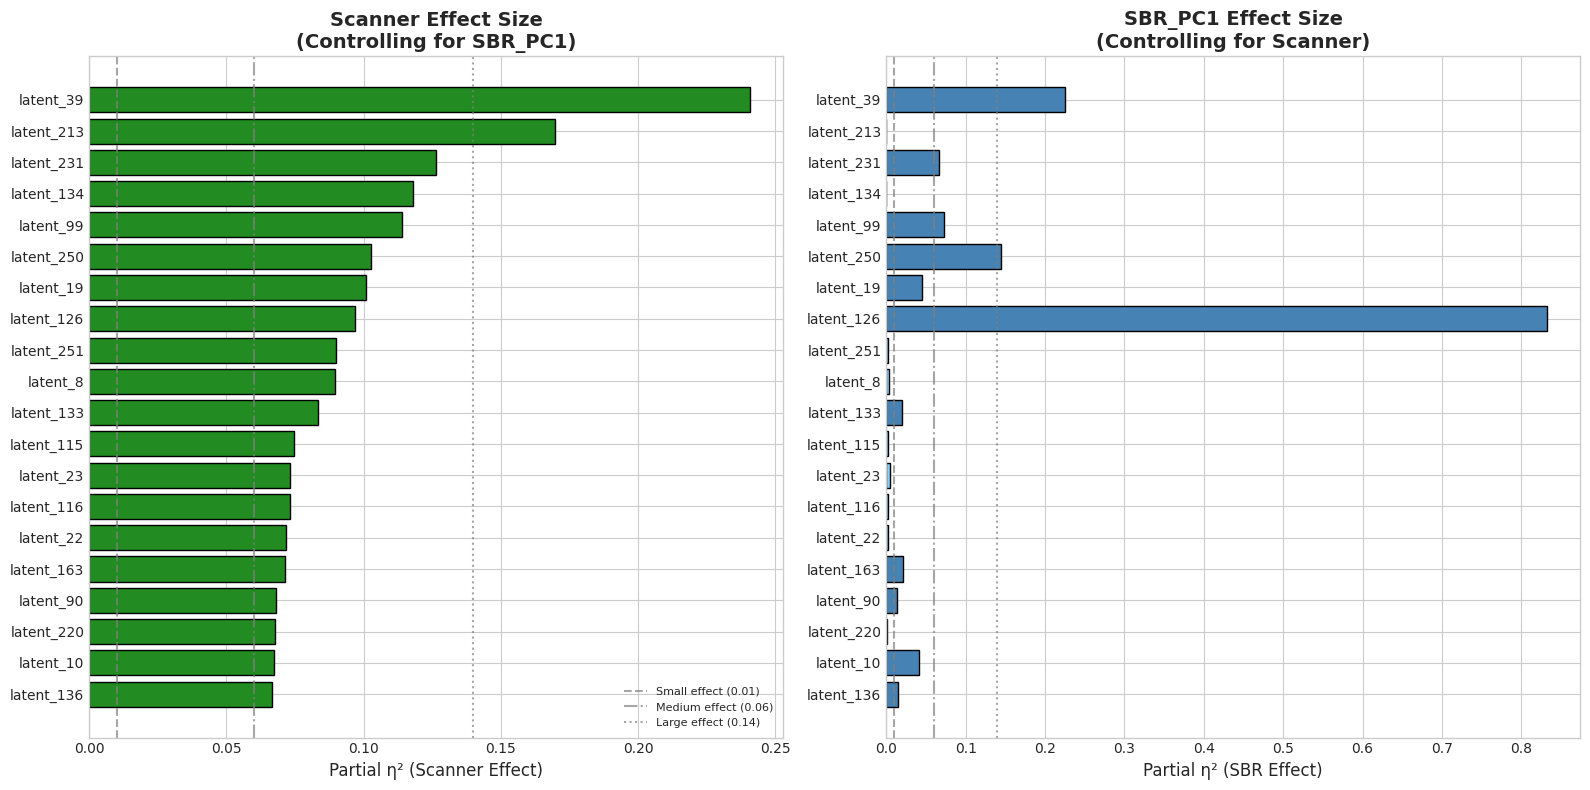


✓ Saved: output/ancova_effect_sizes_comparison.png


In [609]:
# Visualization 1: Bar plot comparing Scanner vs SBR effect sizes
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 20 dimensions for visualization
top_n = 20
df_top = df_ancova.head(top_n)

# Left plot: Scanner Partial Eta-Squared
ax1 = axes[0]
colors1 = ['forestgreen' if surv else 'lightcoral' 
           for surv in df_top['Scanner_Survives_Bonferroni']]
bars1 = ax1.barh(range(top_n), df_top['Scanner_Partial_Eta_Sq'].values, color=colors1, edgecolor='black')
ax1.set_yticks(range(top_n))
ax1.set_yticklabels(df_top['Dimension'].values, fontsize=10)
ax1.invert_yaxis()
ax1.set_xlabel('Partial η² (Scanner Effect)', fontsize=12)
ax1.set_title(f'Scanner Effect Size\n(Controlling for {covariate_col})', fontsize=14, fontweight='bold')
ax1.axvline(x=0.01, color='gray', linestyle='--', alpha=0.7, label='Small effect (0.01)')
ax1.axvline(x=0.06, color='gray', linestyle='-.', alpha=0.7, label='Medium effect (0.06)')
ax1.axvline(x=0.14, color='gray', linestyle=':', alpha=0.7, label='Large effect (0.14)')
ax1.legend(fontsize=8)

# Right plot: SBR Covariate Partial Eta-Squared
ax2 = axes[1]
colors2 = ['steelblue' if surv else 'lightskyblue' 
           for surv in df_top['Cov_Survives_Bonferroni']]
bars2 = ax2.barh(range(top_n), df_top['Covariate_Partial_Eta_Sq'].values, color=colors2, edgecolor='black')
ax2.set_yticks(range(top_n))
ax2.set_yticklabels(df_top['Dimension'].values, fontsize=10)
ax2.invert_yaxis()
ax2.set_xlabel('Partial η² (SBR Effect)', fontsize=12)
ax2.set_title(f'{covariate_col} Effect Size\n(Controlling for Scanner)', fontsize=14, fontweight='bold')
ax2.axvline(x=0.01, color='gray', linestyle='--', alpha=0.7)
ax2.axvline(x=0.06, color='gray', linestyle='-.', alpha=0.7)
ax2.axvline(x=0.14, color='gray', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.savefig('output/ancova_effect_sizes_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: output/ancova_effect_sizes_comparison.png")

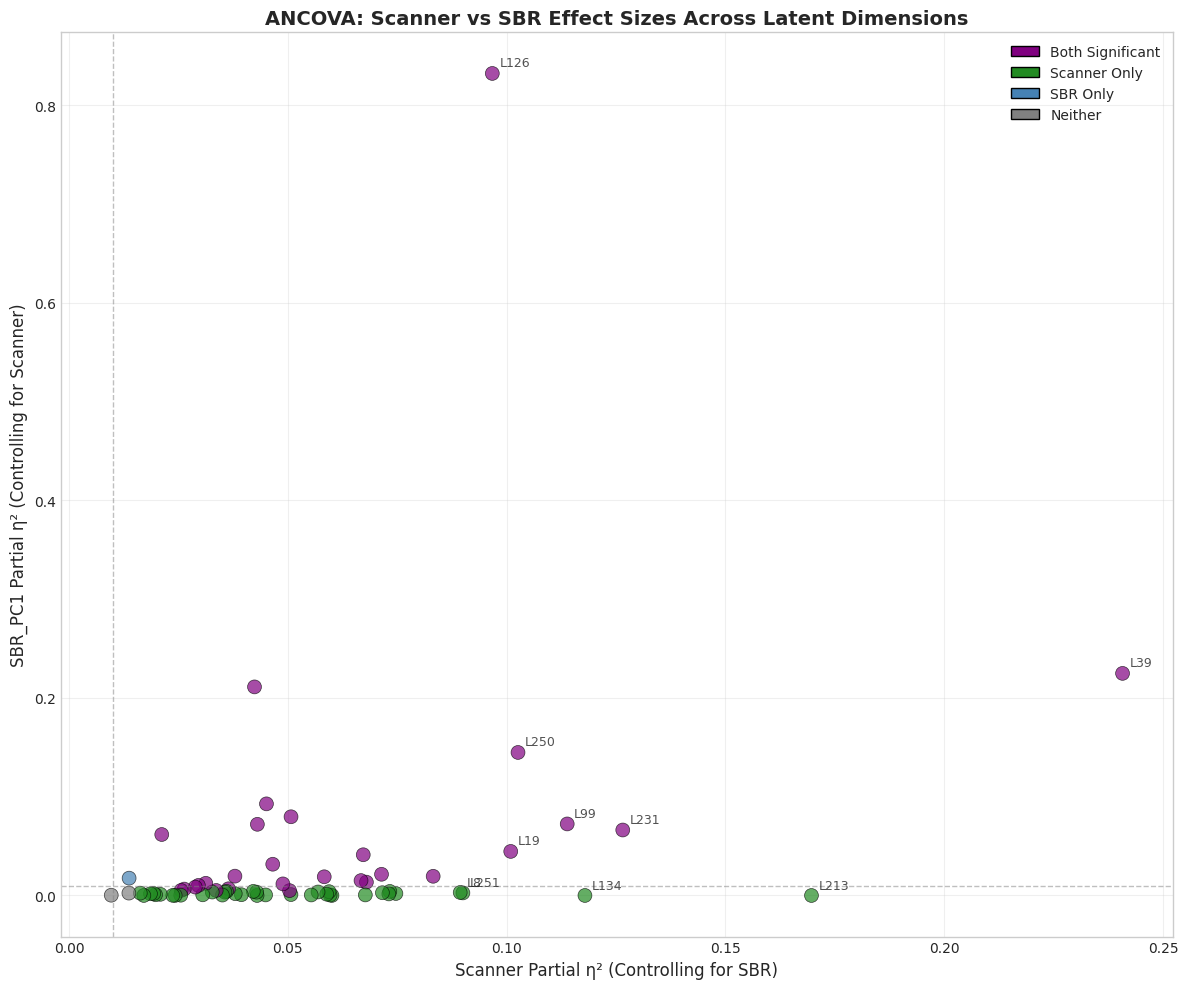


✓ Saved: output/ancova_scanner_vs_sbr_scatter.png


In [610]:
# Visualization 2: Scatter plot - Scanner effect vs SBR effect
fig, ax = plt.subplots(figsize=(12, 10))

# Color by significance
colors = []
labels = []
for _, row in df_ancova.iterrows():
    if row['Scanner_Survives_Bonferroni'] and row['Cov_Survives_Bonferroni']:
        colors.append('purple')
        labels.append('Both Significant')
    elif row['Scanner_Survives_Bonferroni']:
        colors.append('forestgreen')
        labels.append('Scanner Only')
    elif row['Cov_Survives_Bonferroni']:
        colors.append('steelblue')
        labels.append('SBR Only')
    else:
        colors.append('gray')
        labels.append('Neither')

scatter = ax.scatter(
    df_ancova['Scanner_Partial_Eta_Sq'], 
    df_ancova['Covariate_Partial_Eta_Sq'],
    c=colors, alpha=0.7, s=100, edgecolors='black', linewidths=0.5
)

# Add labels for top dimensions
for idx, row in df_ancova.head(10).iterrows():
    ax.annotate(
        row['Dimension'].replace('latent_', 'L'),
        (row['Scanner_Partial_Eta_Sq'], row['Covariate_Partial_Eta_Sq']),
        xytext=(5, 5), textcoords='offset points', fontsize=9, alpha=0.8
    )

ax.set_xlabel('Scanner Partial η² (Controlling for SBR)', fontsize=12)
ax.set_ylabel(f'{covariate_col} Partial η² (Controlling for Scanner)', fontsize=12)
ax.set_title('ANCOVA: Scanner vs SBR Effect Sizes Across Latent Dimensions', fontsize=14, fontweight='bold')

# Add reference lines
ax.axhline(y=0.01, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(x=0.01, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='purple', edgecolor='black', label='Both Significant'),
    Patch(facecolor='forestgreen', edgecolor='black', label='Scanner Only'),
    Patch(facecolor='steelblue', edgecolor='black', label='SBR Only'),
    Patch(facecolor='gray', edgecolor='black', label='Neither')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

# Add grid
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output/ancova_scanner_vs_sbr_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: output/ancova_scanner_vs_sbr_scatter.png")

In [611]:
# Visualization 3: Detailed analysis for Top Scanner-affected dimension
top_dim = df_ancova.iloc[0]['Dimension']

# Re-run ANCOVA to get full model
result = ancova_scanner_effect(df_final, top_dim, scanner_col, covariate_col)
model = result['model']
anova_table = result['anova_table']

print(f"\n{'='*70}")
print(f"Detailed ANCOVA Results for {top_dim}")
print(f"{'='*70}")
print(f"\nANOVA Table (Type II SS):")
print(anova_table)
print(f"\nModel Summary:")
print(model.summary())


Detailed ANCOVA Results for latent_39

ANOVA Table (Type II SS):
                    sum_sq         df          F      PR(>F)
C(Manufacturer) 4.1330e+02 1.5000e+01 4.9782e+01 6.9221e-129
SBR_PC1         3.7820e+02 1.0000e+00 6.8331e+02 1.8158e-132
Residual        1.3034e+03 2.3550e+03        NaN         NaN

Model Summary:
                            OLS Regression Results                            
Dep. Variable:              latent_39   R-squared:                       0.363
Model:                            OLS   Adj. R-squared:                  0.359
Method:                 Least Squares   F-statistic:                     83.93
Date:                Fri, 30 Jan 2026   Prob (F-statistic):          9.76e-217
Time:                        19:27:16   Log-Likelihood:                -2655.6
No. Observations:                2372   AIC:                             5345.
Df Residuals:                    2355   BIC:                             5443.
Df Model:                          16     

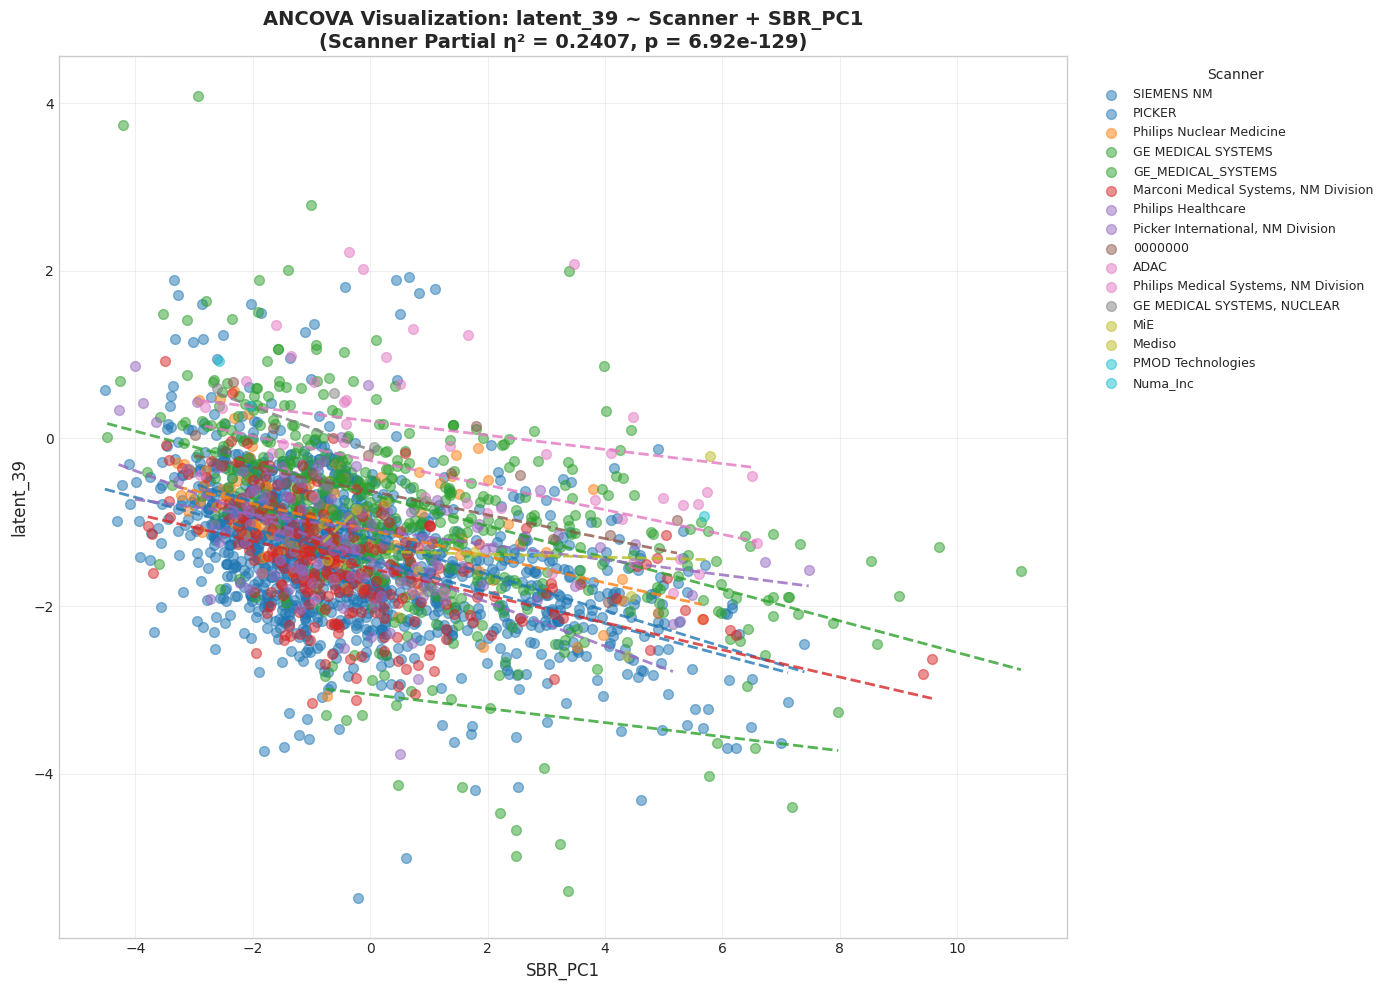


✓ Saved: output/ancova_top_dimension_visualization.png


In [612]:
# Visualization 4: Scatter plot with regression lines by scanner
fig, ax = plt.subplots(figsize=(14, 10))

analysis_df = df_final[[top_dim, scanner_col, covariate_col]].dropna()
scanners = analysis_df[scanner_col].unique()
colors_palette = plt.cm.tab10(np.linspace(0, 1, len(scanners)))

for i, scanner in enumerate(scanners):
    subset = analysis_df[analysis_df[scanner_col] == scanner]
    ax.scatter(subset[covariate_col], subset[top_dim], 
               label=scanner, alpha=0.5, s=50, color=colors_palette[i])
    
    # Add regression line
    if len(subset) > 2:
        z = np.polyfit(subset[covariate_col], subset[top_dim], 1)
        p = np.poly1d(z)
        x_line = np.linspace(subset[covariate_col].min(), subset[covariate_col].max(), 100)
        ax.plot(x_line, p(x_line), '--', color=colors_palette[i], linewidth=2, alpha=0.8)

ax.set_xlabel(f'{covariate_col}', fontsize=12)
ax.set_ylabel(f'{top_dim}', fontsize=12)
ax.set_title(f'ANCOVA Visualization: {top_dim} ~ Scanner + {covariate_col}\n'
             f'(Scanner Partial η² = {result["Scanner_Partial_Eta_Sq"]:.4f}, '
             f'p = {result["Scanner_p"]:.2e})', fontsize=14, fontweight='bold')
ax.legend(title='Scanner', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output/ancova_top_dimension_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: output/ancova_top_dimension_visualization.png")

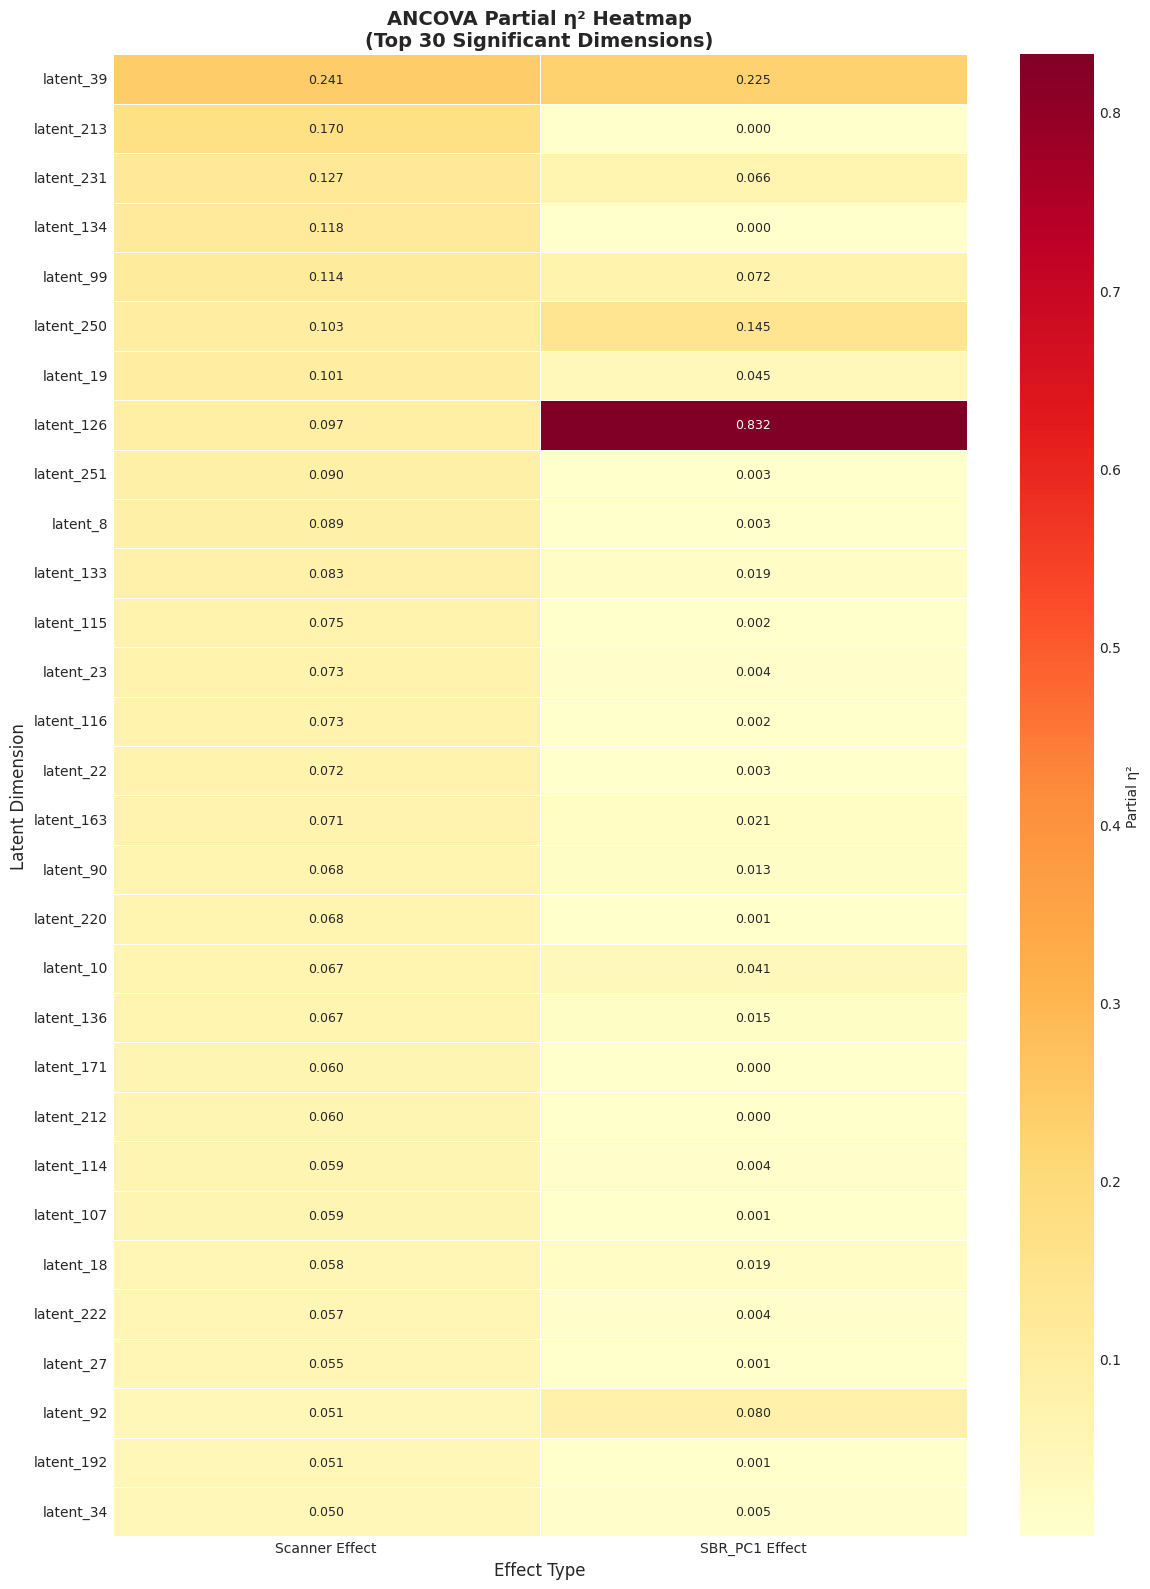


✓ Saved: output/ancova_effect_heatmap.png


In [613]:
# Visualization 5: Heatmap comparing effect sizes
# Create a matrix for heatmap
fig, ax = plt.subplots(figsize=(12, 16))

# Select dimensions that survive Bonferroni correction for either effect
significant_dims = df_ancova[
    df_ancova['Scanner_Survives_Bonferroni'] | df_ancova['Cov_Survives_Bonferroni']
].head(30)

# Create data for heatmap
heatmap_data = significant_dims[['Dimension', 'Scanner_Partial_Eta_Sq', 'Covariate_Partial_Eta_Sq']].copy()
heatmap_data = heatmap_data.set_index('Dimension')
heatmap_data.columns = ['Scanner Effect', f'{covariate_col} Effect']

# Plot heatmap
sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt='.3f', 
    cmap='YlOrRd', 
    ax=ax,
    cbar_kws={'label': 'Partial η²'},
    linewidths=0.5,
    annot_kws={'fontsize': 9}
)
ax.set_title(f'ANCOVA Partial η² Heatmap\n(Top 30 Significant Dimensions)', fontsize=14, fontweight='bold')
ax.set_xlabel('Effect Type', fontsize=12)
ax.set_ylabel('Latent Dimension', fontsize=12)

plt.tight_layout()
plt.savefig('output/ancova_effect_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: output/ancova_effect_heatmap.png")

In [614]:
# Final Summary and Export
print("\n" + "=" * 80)
print("FINAL ANCOVA SUMMARY")
print("=" * 80)

# Classification of dimensions
scanner_only = df_ancova['Scanner_Survives_Bonferroni'] & ~df_ancova['Cov_Survives_Bonferroni']
sbr_only = ~df_ancova['Scanner_Survives_Bonferroni'] & df_ancova['Cov_Survives_Bonferroni']
both = df_ancova['Scanner_Survives_Bonferroni'] & df_ancova['Cov_Survives_Bonferroni']
neither = ~df_ancova['Scanner_Survives_Bonferroni'] & ~df_ancova['Cov_Survives_Bonferroni']

print(f"\nDimension Classification (after Bonferroni correction):")
print(f"  Scanner effect ONLY: {scanner_only.sum()} dimensions")
print(f"  SBR effect ONLY: {sbr_only.sum()} dimensions")
print(f"  BOTH effects: {both.sum()} dimensions")
print(f"  NEITHER effect: {neither.sum()} dimensions")

print(f"\nTop 5 Scanner-dominated dimensions (controlling for SBR):")
for idx, row in df_ancova[scanner_only].head(5).iterrows():
    print(f"  {row['Dimension']}: η² = {row['Scanner_Partial_Eta_Sq']:.4f}, p = {row['Scanner_p']:.2e}")

print(f"\nTop 5 SBR-dominated dimensions (controlling for Scanner):")
for idx, row in df_ancova[sbr_only].sort_values('Covariate_Partial_Eta_Sq', ascending=False).head(5).iterrows():
    print(f"  {row['Dimension']}: η² = {row['Covariate_Partial_Eta_Sq']:.4f}, p = {row['Covariate_p']:.2e}")

# Export results
output_file = f'output/ancova_results_scanner_vs_{covariate_col}.csv'
df_ancova.to_csv(output_file, index=False)
print(f"\n✓ Results exported to: {output_file}")


FINAL ANCOVA SUMMARY

Dimension Classification (after Bonferroni correction):
  Scanner effect ONLY: 36 dimensions
  SBR effect ONLY: 1 dimensions
  BOTH effects: 28 dimensions
  NEITHER effect: 2 dimensions

Top 5 Scanner-dominated dimensions (controlling for SBR):
  latent_213: η² = 0.1697, p = 4.27e-84
  latent_134: η² = 0.1179, p = 3.46e-54
  latent_251: η² = 0.0900, p = 5.05e-39
  latent_8: η² = 0.0894, p = 1.07e-38
  latent_115: η² = 0.0747, p = 5.21e-31

Top 5 SBR-dominated dimensions (controlling for Scanner):
  latent_216: η² = 0.0176, p = 1.07e-10

✓ Results exported to: output/ancova_results_scanner_vs_SBR_PC1.csv


In [615]:
# Optional: Run with SBR_PC2 instead
covariate_col_2 = 'SBR_PC2'
ancova_results_pc2 = []

for dim in ACTIVE_FEATURES:
    try:
        result = ancova_scanner_effect(
            df_final, 
            latent_dim=dim, 
            scanner_col=scanner_col,
            covariate_col=covariate_col_2
        )
        result_for_df = {k: v for k, v in result.items() if k not in ['anova_table', 'model']}
        ancova_results_pc2.append(result_for_df)
    except Exception as e:
        pass

df_ancova_pc2 = pd.DataFrame(ancova_results_pc2)
df_ancova_pc2['Scanner_Survives_Bonferroni'] = df_ancova_pc2['Scanner_p'] < ALPHA_CORRECTED
df_ancova_pc2 = df_ancova_pc2.sort_values('Scanner_Partial_Eta_Sq', ascending=False)

print(f"\n{'='*70}")
print(f"ANCOVA Results with {covariate_col_2} as Covariate")
print(f"{'='*70}")
print(f"Dimensions with significant Scanner effect: {df_ancova_pc2['Scanner_Survives_Bonferroni'].sum()}")

# Export
df_ancova_pc2.to_csv(f'output/ancova_results_scanner_vs_{covariate_col_2}.csv', index=False)


ANCOVA Results with SBR_PC2 as Covariate
Dimensions with significant Scanner effect: 63
